## 1.0 BUSINESS PROBLEM 
Our company is expanding into new industries by purchasing and operating aircraft for both commercial and private enterprises. To ensure a successful entry into this market, it is crucial to identify aircraft with the lowest potential risk of accidents.

## 1.1 PROBLEM STATEMENT
The primary challenge in selecting an aircraft is evaluating its historical safety performance to minimize the risk of accidents.

## 1.2 METRICS OF SUCCESS
To gauge the success of this analysis and assist the head of the new aviation division in making informed decisions about aircraft purchases, the following metrics will be used:

1. **Clarity and Actionability of Recommendations:**
   - **Objective:** Provide clear and actionable recommendations for aircraft selection.
   - **Measure:** Evaluate how well the recommendations align with the company's risk tolerance and operational requirements.

2. **Industry Standards Compliance:**
   - **Objective:** Ensure that the recommendations are consistent with industry safety standards and best practices.
   - **Measure:** Review recommendations against established safety ratings and industry benchmarks.



In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [30]:
#Reading the data
Aviation_data=pd.read_csv('AviationData.csv',encoding='cp1252',low_memory=False)
#print(Aviation_data.head())
Us_state_codes=pd.read_csv('USState_Codes.csv',encoding='cp1252',low_memory=False)

In [31]:
Aviation_data.info()
'''
The dataset has:
82,474 rows (entries)
31 columns, including:
6 float variables
26 object data types
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50249 non-null  object 
 9   Airport.Name            52790 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87572 non-null  object 
 14  Make                    88826 non-null

'\nThe dataset has:\n82,474 rows (entries)\n31 columns, including:\n6 float variables\n26 object data types\n'

# 2.0 DATA MANIPULATION

In [32]:
#check for missing values composition
missing_values=Aviation_data.isnull().sum()
#missing_values_percentage=missing_values[2]
sorted_values=missing_values.sort_values(ascending=False)
total_rows = Aviation_data.shape[0]
missing_values_percentage=(missing_values/total_rows)*100
missing_values_percentage=missing_values_percentage.sort_values(ascending=False).round(0)

# We will drop all columns with missing values composition of 30% and above.
#The columns Schedule Air.carrier, FAR.Description, Aircraft.Category, Longitude,
# Latitude, Airport.Code, Airport.Name and Broad.phase.of.flight will be dropped 
above_threshold=missing_values_percentage>30.0
#print(missing_values_percentage)
print("Columns with missing values above 30% threshold:")
print(missing_values_percentage)
#print(sorted_values)
'''
columns having missing values above 30% threshold:
Schedule                  86.0
Air.carrier               81.0
FAR.Description           64.0
Aircraft.Category         64.0
Longitude                 61.0
Latitude                  61.0
Airport.Code              43.0
Airport.Name              41.0
Broad.phase.of.flight     31.0
'''

Columns with missing values above 30% threshold:
Schedule                  86.0
Air.carrier               81.0
FAR.Description           64.0
Aircraft.Category         64.0
Longitude                 61.0
Latitude                  61.0
Airport.Code              43.0
Airport.Name              41.0
Broad.phase.of.flight     31.0
Publication.Date          15.0
Total.Serious.Injuries    14.0
Total.Minor.Injuries      13.0
Total.Fatal.Injuries      13.0
Engine.Type                8.0
Report.Status              7.0
Purpose.of.flight          7.0
Number.of.Engines          7.0
Total.Uninjured            7.0
Weather.Condition          5.0
Aircraft.damage            4.0
Registration.Number        1.0
Injury.Severity            1.0
Country                    0.0
Amateur.Built              0.0
Model                      0.0
Make                       0.0
Location                   0.0
Event.Date                 0.0
Accident.Number            0.0
Investigation.Type         0.0
Event.Id             

'\ncolumns having missing values above 30% threshold:\nSchedule                  86.0\nAir.carrier               81.0\nFAR.Description           64.0\nAircraft.Category         64.0\nLongitude                 61.0\nLatitude                  61.0\nAirport.Code              43.0\nAirport.Name              41.0\nBroad.phase.of.flight     31.0\n'

In [33]:
# drop the columns with over 30% of missing values
columns_to_drop=missing_values_percentage[above_threshold]
columns_to_drop=columns_to_drop.index

for col in columns_to_drop:
    Aviation_data.drop(columns=col,inplace=True)
print(Aviation_data.shape) # indicates that the new dataframe contains 88,889 rows and 22 columns

(88889, 22)


In [34]:
#drop other irrelevant columns that i may not need in my analysis
Aviation_data=Aviation_data.drop(columns=['Publication.Date'])
Aviation_data=Aviation_data.drop(columns=['Registration.Number'])
Aviation_data.columns # Returns the resultant columns in our dataframe

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Injury.Severity', 'Aircraft.damage', 'Make',
       'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Report.Status'],
      dtype='object')

In [35]:
#convert columns make/model cells to contain upper case Strings
Aviation_data['Make']=Aviation_data['Make'].str.upper()
Aviation_data['Make']=Aviation_data['Make'].str.strip()
Aviation_data['Model']=Aviation_data['Model'].str.upper()

#print(sorted_by_index_and_values.iloc[1:100]) '''

In [36]:
print(Aviation_data.describe(include=object).T) #show a summary of all variables in our dataframe

'''
Investigation Type and Amateur.Built, have two unique categories. Aircraft.damage and Weather.Condition have 4 unique categories.
Event.Id,Accident.Number have huge number of uniques entries.
'''

                    count unique             top   freq
Event.Id            88889  87951  20001212X19172      3
Investigation.Type  88889      2        Accident  85015
Accident.Number     88889  88863      CEN22LA149      2
Event.Date          88889  14782      2000-07-08     25
Location            88837  27758   ANCHORAGE, AK    434
Country             88663    219   United States  82248
Injury.Severity     87889    109       Non-Fatal  67357
Aircraft.damage     85695      4     Substantial  64148
Make                88826   7587          CESSNA  27149
Model               88797  11646             152   2367
Amateur.Built       88787      2              No  80312
Engine.Type         81812     13   Reciprocating  69530
Purpose.of.flight   82697     26        Personal  49448
Weather.Condition   84397      4             VMC  77303
Report.Status       82508  17075  Probable Cause  61754


'\nInvestigation Type and Amateur.Built, have two unique categories. Aircraft.damage and Weather.Condition have 4 unique categories.\nEvent.Id,Accident.Number have huge number of uniques entries.\n'

In [37]:
# calculate the mean values for numerical data type variables in our dataset
mean_values=Aviation_data.mean().round(0)
mean_values

Number.of.Engines         1.0
Total.Fatal.Injuries      1.0
Total.Serious.Injuries    0.0
Total.Minor.Injuries      0.0
Total.Uninjured           5.0
dtype: float64

In [38]:
# we will replace all missing values in all columns with numerical data types using the mean values
numerical_colums=mean_values.index
for i in numerical_colums:
    Aviation_data.fillna(mean_values,inplace=True)
print(Aviation_data.isna().sum())

Event.Id                     0
Investigation.Type           0
Accident.Number              0
Event.Date                   0
Location                    52
Country                    226
Injury.Severity           1000
Aircraft.damage           3194
Make                        63
Model                       92
Amateur.Built              102
Number.of.Engines            0
Engine.Type               7077
Purpose.of.flight         6192
Total.Fatal.Injuries         0
Total.Serious.Injuries       0
Total.Minor.Injuries         0
Total.Uninjured              0
Weather.Condition         4492
Report.Status             6381
dtype: int64


In [39]:
#Summarize numerical variables
Aviation_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Number.of.Engines,88889.0,1.136552,0.432545,0.0,1.0,1.0,1.0,8.0
Total.Fatal.Injuries,88889.0,0.693022,5.123423,0.0,0.0,0.0,1.0,349.0
Total.Serious.Injuries,88889.0,0.240491,1.434614,0.0,0.0,0.0,0.0,161.0
Total.Minor.Injuries,88889.0,0.309127,2.083715,0.0,0.0,0.0,0.0,380.0
Total.Uninjured,88889.0,5.303795,26.969508,0.0,0.0,1.0,2.0,699.0


- Number of Engines: Most aircraft have a single engine, with a small number having up to 8 engines.
- Total Fatal Injuries: Most incidents result in no fatalities, but there is significant variability, 
with a few incidents having very high fatality counts.
- Total Serious Injuries: Serious injuries are rare and mostly zero, though some incidents report up to 161 serious injuries.
- Total Minor Injuries: Minor injuries are generally low, with occasional incidents reporting up to 380 minor injuries.
- Total Uninjured: The average number of uninjured individuals per incident is high, but there is a wide range,
with some incidents involving up to 699 uninjured people.


In [40]:
#summarize all variables including categorical variables
categorical_variables=Aviation_data.describe(include=object).T.index
for i in categorical_variables:
    mode_value = Aviation_data[i].mode()[0]  # Get the first mode for the column
    Aviation_data[i].fillna(mode_value, inplace=True)  # Fill missing values with mode
# Print the number of missing values in each column
print(Aviation_data.isna().sum())
'''
The dataset has no missing values at this level
'''

Event.Id                  0
Investigation.Type        0
Accident.Number           0
Event.Date                0
Location                  0
Country                   0
Injury.Severity           0
Aircraft.damage           0
Make                      0
Model                     0
Amateur.Built             0
Number.of.Engines         0
Engine.Type               0
Purpose.of.flight         0
Total.Fatal.Injuries      0
Total.Serious.Injuries    0
Total.Minor.Injuries      0
Total.Uninjured           0
Weather.Condition         0
Report.Status             0
dtype: int64


'\nThe dataset has no missing values at this level\n'

In [41]:
#format Event.Date column and add an extra column called year.
#Extract year from Event.Date and create a new column called year
Aviation_data['Event.Date'] = pd.to_datetime(Aviation_data['Event.Date'], format='%Y-%m-%d')
# Extract just the year part
Aviation_data['Year']=Aviation_data['Event.Date'].dt.strftime('%Y')
#print(Aviation_data['Year'].value_counts())

In [42]:
# we will analyze the number of aircrafts per country
Aviation_data['Country'].value_counts()
'''
Most aircraft accidents operate in the United States as shown below:
United States                       82474
Brazil                                374
Canada                                359
Mexico                                358
United Kingdom                        344
'''
#we will then pick to analyze our data for United states since most of the airctafts are operated there
Aviation_data=Aviation_data[Aviation_data['Country']=='United States']


In [43]:
#Accidents vs incidents
Aviation_data['Investigation.Type'].value_counts()
'''
Accidents form majority of the Investigation Types conducted as compared to Incident type
'''	

'\nAccidents form majority of the Investigation Types conducted as compared to Incident type\n'

In [44]:
# our second dataset called 'Us_state codes' needs to be cleaned and merged with our first dataset called "Aviation_data"
# Extract the state or location code from the 'Location' column
# Split the 'Location' string by commas
# Select the second part (index 1) of the split string which should be the state code
# Remove any leading or trailing whitespace from the extracted string
Aviation_data['Location_code']=Aviation_data['Location'].str.split(',').str[1].str.strip()

# Remove any leading or trailing whitespace from the 'Abbreviation' column in the Us_state_codes DataFrame
Us_state_codes['Abbreviation']=Us_state_codes['Abbreviation'].str.strip()

In [45]:
#Merge the two data frame on Location code
Clean_aviation_data=pd.merge(Aviation_data,Us_state_codes,how='left',left_on='Location_code', right_on='Abbreviation')
Missing_data=Clean_aviation_data.isna().sum()
for col in Clean_aviation_data.columns:
    if Missing_data[col]>0:
          col_mode=Clean_aviation_data[col].mode()[0]
          Clean_aviation_data[col].fillna(col_mode,inplace=True)
print(Clean_aviation_data.isna().sum())


Event.Id                  0
Investigation.Type        0
Accident.Number           0
Event.Date                0
Location                  0
Country                   0
Injury.Severity           0
Aircraft.damage           0
Make                      0
Model                     0
Amateur.Built             0
Number.of.Engines         0
Engine.Type               0
Purpose.of.flight         0
Total.Fatal.Injuries      0
Total.Serious.Injuries    0
Total.Minor.Injuries      0
Total.Uninjured           0
Weather.Condition         0
Report.Status             0
Year                      0
Location_code             0
US_State                  0
Abbreviation              0
dtype: int64


In [46]:
#Replace all engine types indicated as 'None','NONE' to Unknown as a valid category
Clean_aviation_data['Engine.Type'] = Clean_aviation_data['Engine.Type'].replace(['NONE','None'], 'Unknown')

In [47]:
Clean_aviation_data_merged=Clean_aviation_data.copy() # Making a copy of our clean_aviation_data
Clean_aviation_data_merged.to_csv("Clean_merged_data.csv",index=False)
Clean_aviation_data_merged.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,...,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Report.Status,Year,Location_code,US_State,Abbreviation
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,Fatal(2),Destroyed,STINSON,108-3,...,2.0,0.0,0.0,0.0,UNK,Probable Cause,1948,ID,Idaho,ID
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,PIPER,PA24-180,...,4.0,0.0,0.0,0.0,UNK,Probable Cause,1962,CA,California,CA
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,Fatal(3),Destroyed,CESSNA,172M,...,3.0,0.0,0.0,5.0,IMC,Probable Cause,1974,VA,Virginia,VA
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,ROCKWELL,112,...,2.0,0.0,0.0,0.0,IMC,Probable Cause,1977,CA,California,CA
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,Fatal(1),Destroyed,CESSNA,501,...,1.0,2.0,0.0,0.0,VMC,Probable Cause,1979,OH,Ohio,OH


## 3.0  DATA ANALYIS AND VISUALIZATION

In [48]:
#Accidents vs incidents
Clean_aviation_data_merged['Investigation.Type'].value_counts()
# Count the occurrences of each Investigation Type
'''
Accidents form a huge junk of the type of aircraft investigations i.e., 
80112 as compared to Incident type of investigation i.e.,2362
'''


'\nAccidents form a huge junk of the type of aircraft investigations i.e., \n80112 as compared to Incident type of investigation i.e.,2362\n'

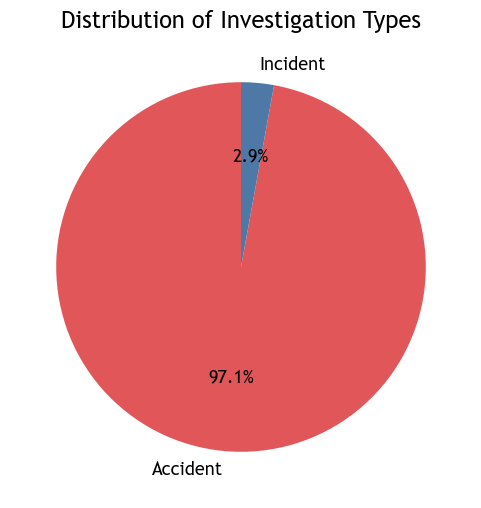

'\nAccidents comprise 97% of all Investigations done whereas Incidences comprise 3%.\n'

In [49]:
#Graphical representation of type of investigations in a pie chart
investigation_type_counts = Clean_aviation_data_merged['Investigation.Type'].value_counts()
# Create the pie chart
font_properties = {'fontname': 'Trebuchet MS', 'fontsize': 13}
plt.figure(figsize=(6, 6),facecolor='white')
plt.pie(investigation_type_counts, 
        labels=investigation_type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#e15759', '#4e79a7'],
        textprops=font_properties)

# Equal aspect ratio ensures that pie is drawn as a circle
#plt.axis('equal')

# Title for the chart
plt.title('Distribution of Investigation Types',fontname='Trebuchet Ms',fontsize=17)

# Show the pie chart
plt.show()
'''
Accidents comprise 97% of all Investigations done whereas Incidences comprise 3%.
'''

In [50]:
#To categorise accidents per make and model
#Aircraft_make analysis for number of accidents since accidents form 97% of the Inestigation Type.
Aircraft_accidents=Clean_aviation_data[Clean_aviation_data['Investigation.Type']=='Accident']
Aircraft_Accidents_Makewise=Clean_aviation_data.groupby('Make').size().sort_values(ascending=False)
Aircraft_Accidents_Modelwise=Clean_aviation_data.groupby('Model').size().sort_values(ascending=False)
#Top 10 Airctaft makes and models with high number of accidents
print(f'Top Airctaft Makes with many accidents:\n{Aircraft_Accidents_Makewise.head(10)}')
print(f'Top Airctaft Models with many accidents:\n{Aircraft_Accidents_Modelwise.head(10)}')

'''
Aircraft Makes:
CESSNA and PIPER are the most frequently involved in accidents.
BOEING and BELL, while having fewer accidents compared to CESSNA and PIPER, still have significant numbers. 

Aircraft Models:
152 and 172 are the most frequently involved models in accidents, reflecting their high usage.
PA-28-140 and 150 also show notable accident rates, which could be linked to their operational contexts or frequency of use.

'''

Top Airctaft Makes with many accidents:
Make
CESSNA      25917
PIPER       14193
BEECH        5067
BELL         2352
BOEING       1494
MOONEY       1294
GRUMMAN      1145
BELLANCA     1040
ROBINSON      924
HUGHES        879
dtype: int64
Top Airctaft Models with many accidents:
Model
152          2362
172          1639
172N         1139
PA-28-140     911
150           791
172M          776
172P          681
180           617
182           589
150M          579
dtype: int64


'\nAircraft Makes:\nCESSNA and PIPER are the most frequently involved in accidents.\nBOEING and BELL, while having fewer accidents compared to CESSNA and PIPER, still have significant numbers. \n\nAircraft Models:\n152 and 172 are the most frequently involved models in accidents, reflecting their high usage.\nPA-28-140 and 150 also show notable accident rates, which could be linked to their operational contexts or frequency of use.\n\n'

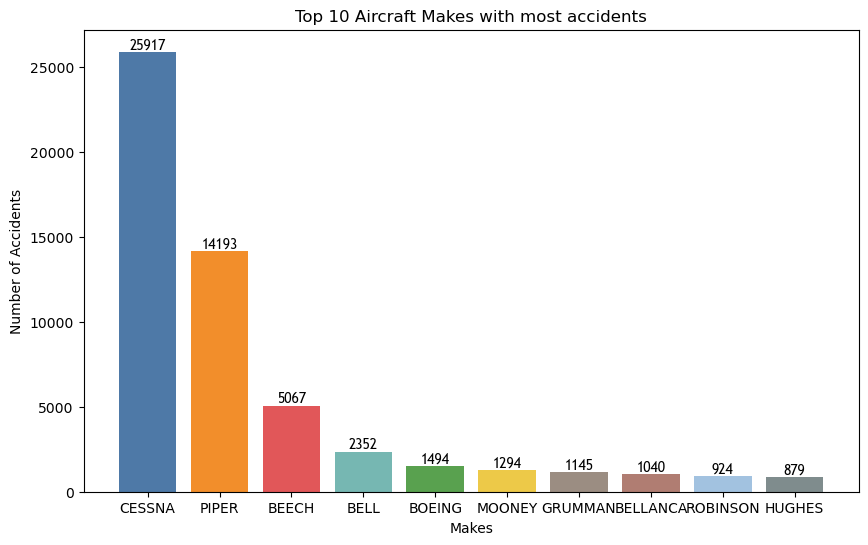

In [51]:
top_aircraft_count_figure, ax = plt.subplots(figsize=(10, 6))
bar_chart_title = 'Top 10 Aircraft Makes with most accidents'
bar_chart_count_label = 'Number of Accidents'
bar_chart_series_label = 'Makes'
x = Aircraft_Accidents_Makewise.head(10).index
#print (x)
heights = Aircraft_Accidents_Makewise.head(10).values

#ax.bar(x, heights)
# Add data labels on top of the bars
bars=ax.bar(x, heights,color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', 
          '#9b8d82', '#b07d72', '#a2c2e0', '#7f8c8d'])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        height,  # Y-coordinate: top of the bar
        f'{height}',  # Text: height of the bar
        ha='center',  # Horizontal alignment: center
        va='bottom', 
        fontname='Trebuchet Ms'  # Vertical alignment: just above the bar
    )
# title
ax.set_title(bar_chart_title)
# x-axis label
ax.set_xlabel(bar_chart_series_label)
# y-axis label
ax.set_ylabel(bar_chart_count_label)
# Display the chart
plt.show()

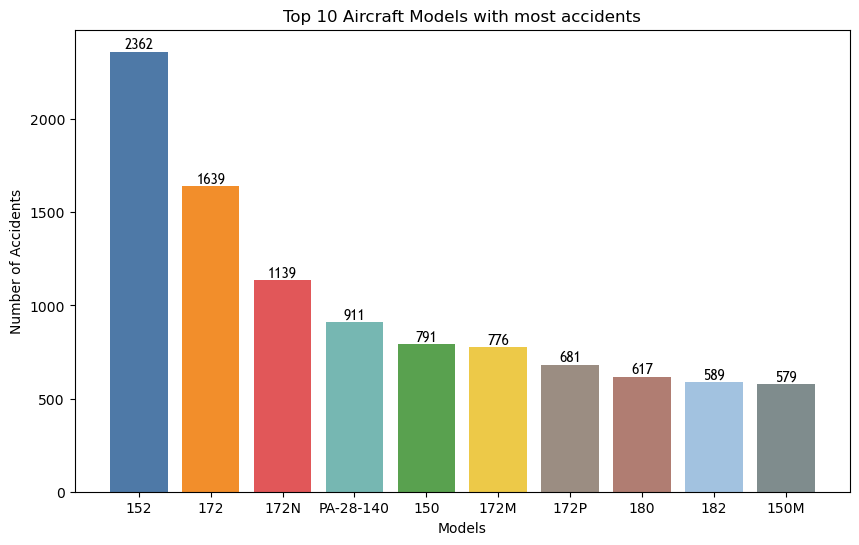

In [52]:
top_aircraft_count_figure, ax = plt.subplots(figsize=(10, 6))
bar_chart_title = 'Top 10 Aircraft Models with most accidents'
bar_chart_count_label = 'Number of Accidents'
bar_chart_series_label = 'Models'
x = Aircraft_Accidents_Modelwise.head(10).index
#print (x)
heights = Aircraft_Accidents_Modelwise.head(10).values

#ax.bar(x, heights)
# Add data labels on top of the bars
bars=ax.bar(x, heights,color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', 
          '#9b8d82', '#b07d72', '#a2c2e0', '#7f8c8d'])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        height,  # Y-coordinate: top of the bar
        f'{height}',  # Text: height of the bar
        ha='center',  # Horizontal alignment: center
        va='bottom', 
        fontname='Trebuchet Ms'  # Vertical alignment: just above the bar
    )
# title
ax.set_title(bar_chart_title)
# x-axis label
ax.set_xlabel(bar_chart_series_label)
# y-axis label
ax.set_ylabel(bar_chart_count_label)
# Display the chart
plt.show()

In [53]:
#Weather Condition Analysis for Aircraft Accidents
Weather_cond_accidents=Aircraft_accidents.groupby('Weather.Condition').size().sort_values(ascending=False)
print(Weather_cond_accidents)
'''
VMC weather conditions exhibit huge accidents  as compared to IMC and other weather condition categories.
'''

Weather.Condition
VMC    74090
IMC     5402
UNK      523
Unk       97
dtype: int64


'\nVMC weather conditions exhibit huge accidents  as compared to IMC and other weather condition categories.\n'

In [54]:
Clean_aviation_data_merged.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Injury.Severity', 'Aircraft.damage', 'Make',
       'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Report.Status', 'Year', 'Location_code', 'US_State', 'Abbreviation'],
      dtype='object')

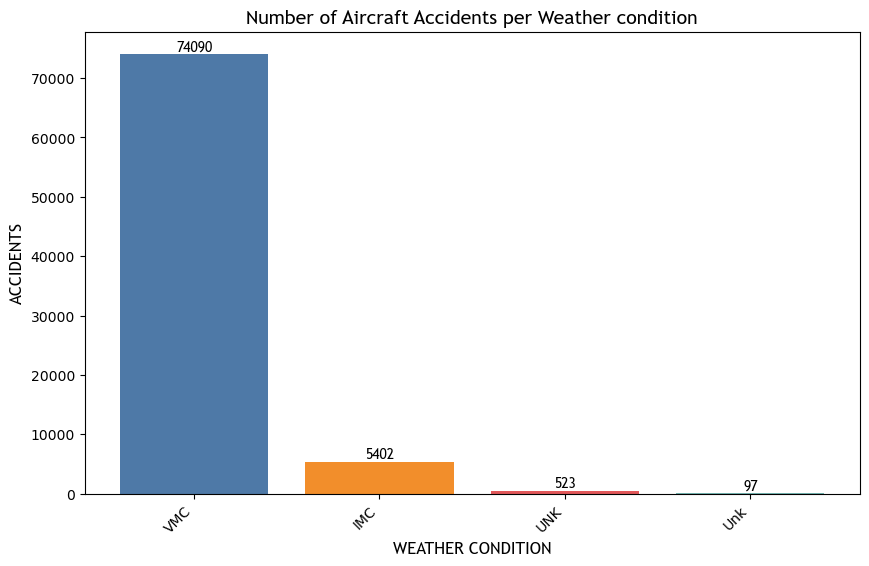

In [55]:
# Create the bar chart
Weather_cond_figure, ax = plt.subplots(figsize=(10, 6))
x=Weather_cond_accidents.index
heights=Weather_cond_accidents.values

bar_chart_title ='Number of Aircraft Accidents per Weather condition'
bar_chart_count_label = 'ACCIDENTS'
bar_chart_series_label = 'WEATHER CONDITION'

bars=ax.bar(x, heights,color = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        height,  # Y-coordinate: top of the bar
        f'{height}',  # Text: height of the bar
        ha='center',  # Horizontal alignment: center
        va='bottom', 
        fontname='Trebuchet MS'  # Vertical alignment: just above the bar
    )

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# title
ax.set_title(bar_chart_title, fontname='Trebuchet MS',fontsize=14)
# x-axis label
ax.set_xlabel(bar_chart_series_label, fontname='Trebuchet MS',fontsize=12)
# y-axis label
ax.set_ylabel(bar_chart_count_label, fontname='Trebuchet MS', fontsize=12)
# Display the chart
plt.show()

In [56]:
#Location with the highest number of Airctaft Accidents
Accidents_location=Aircraft_accidents.groupby('Location').size().sort_values(ascending=False).head(10)
print(Accidents_location.head(10))
'''
ANCHORAGE, AK experinec majority number of accidents  as compared to  ALBUQUERQUE, NM and other regions.
'''

Location
ANCHORAGE, AK      417
ALBUQUERQUE, NM    192
HOUSTON, TX        174
FAIRBANKS, AK      169
MIAMI, FL          158
TUCSON, AZ         141
PHOENIX, AZ        131
ENGLEWOOD, CO      130
ORLANDO, FL        117
SAN DIEGO, CA      117
dtype: int64


'\nANCHORAGE, AK experinec majority number of accidents  as compared to  ALBUQUERQUE, NM and other regions.\n'

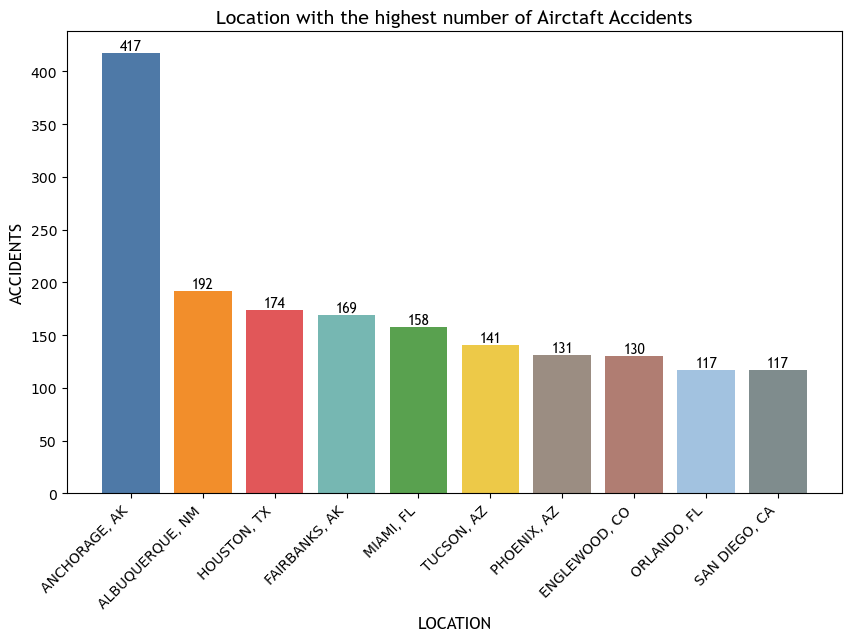

In [57]:
# Create the bar chart
model_count_figure, ax = plt.subplots(figsize=(10, 6))
x=Accidents_location.index
heights=Accidents_location.values

#bar_chart_locations = ['England', 'Germany', 'Spain', 'France', 'Argentina']

bar_chart_title ='Location with the highest number of Airctaft Accidents'
bar_chart_count_label = 'ACCIDENTS'
bar_chart_series_label = 'LOCATION'

bars=ax.bar(x, heights,color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', 
          '#9b8d82', '#b07d72', '#a2c2e0', '#7f8c8d'])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        height,  # Y-coordinate: top of the bar
        f'{height}',  # Text: height of the bar
        ha='center',  # Horizontal alignment: center
        va='bottom', 
        fontname='Trebuchet MS'  # Vertical alignment: just above the bar
    )

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# title
ax.set_title(bar_chart_title, fontname='Trebuchet MS',fontsize=14)
# x-axis label
ax.set_xlabel(bar_chart_series_label, fontname='Trebuchet MS',fontsize=12)
# y-axis label
ax.set_ylabel(bar_chart_count_label, fontname='Trebuchet MS', fontsize=12)
# Display the chart
plt.show()

In [58]:
#Purpose of flight analysis
Accidents_by_purpose_of_flight=Clean_aviation_data_merged['Purpose.of.flight'].value_counts()
#Top 10 flight purpose by Accidents
top_10_purpose_by_accidents=Accidents_by_purpose_of_flight.head(10)
print(top_10_purpose_by_accidents)
'''
Aircrafts used for Personal reasons experienced a huge number of accidents i.e. 51,035 as compared to those
used for business purpose which experienced 3,856 accidents
'''

Personal              51035
Instructional         10440
Unknown                5839
Aerial Application     4627
Business               3856
Positioning            1584
Other Work Use         1197
Ferry                   733
Aerial Observation      714
Public Aircraft         687
Name: Purpose.of.flight, dtype: int64


'\nAircrafts used for Personal reasons experienced a huge number of accidents i.e. 51,035 as compared to those\nused for business purpose which experienced 3,856 accidents\n'

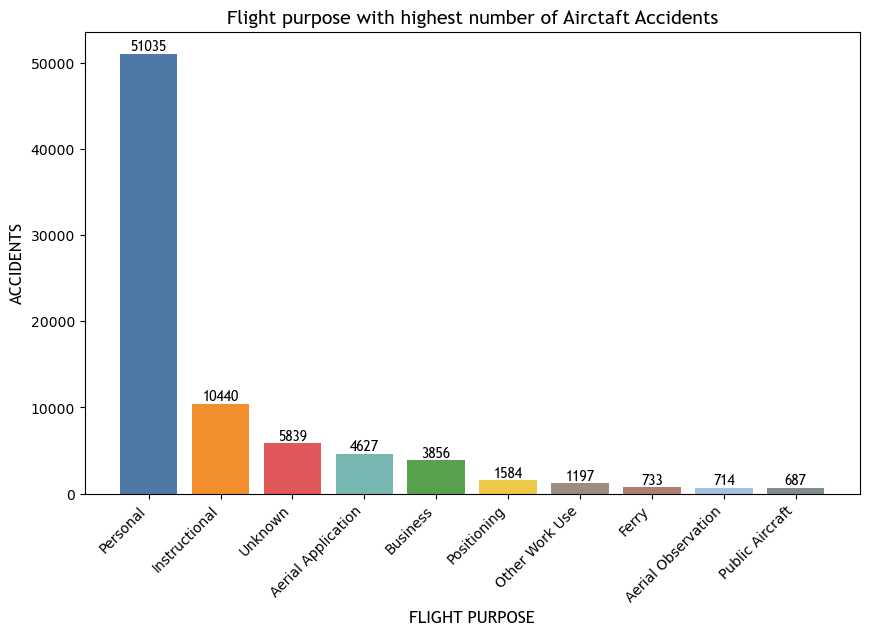

In [59]:
flight_purpose_count_figure, ax = plt.subplots(figsize=(10, 6),)
Flight_purpose=Clean_aviation_data_merged
x=top_10_purpose_by_accidents.index
heights=top_10_purpose_by_accidents.values
bar_chart_title ='Flight purpose with highest number of Airctaft Accidents'
bar_chart_count_label = 'ACCIDENTS'
bar_chart_series_label = 'FLIGHT PURPOSE'

bars=ax.bar(x, heights,color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', 
          '#9b8d82', '#b07d72', '#a2c2e0', '#7f8c8d'])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        height,  # Y-coordinate: top of the bar
        f'{height}',  # Text: height of the bar
        ha='center',  # Horizontal alignment: center
        va='bottom', 
        fontname='Trebuchet MS'  # Vertical alignment: just above the bar
    )

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# title
ax.set_title(bar_chart_title, fontname='Trebuchet MS',fontsize=14)
# x-axis label
ax.set_xlabel(bar_chart_series_label, fontname='Trebuchet MS',fontsize=12)
# y-axis label
ax.set_ylabel(bar_chart_count_label, fontname='Trebuchet MS', fontsize=12)
# Display the chart
plt.show()

In [60]:

# Analyzing engine types
Engine_types = Clean_aviation_data_merged['Engine.Type'].value_counts()
print(Engine_types)

'''
Analysis of Engine Types:

Reciprocating engines dominate the dataset, accounting for the vast majority of cases with 71,646 entries. 
This suggests that reciprocating engines are the most commonly used type of engine in the analyzed aircraft accidents.
Other engine types such as Turbo Shaft, Turbo Prop, and Turbo Fan appear significantly less frequently in the data.
Here is the breakdown of the engine types:
1. **Reciprocating**: 71,646
2. **Turbo Shaft**: 3,416
3. **Turbo Prop**: 3,217
4. **Turbo Fan**: 2,101
5. **Unknown**: 1,390
6. **Turbo Jet**: 669

The dominance of reciprocating engines could imply that smaller, general aviation aircraft (which commonly use these engines) are more prone to accidents, or simply more prevalent in the dataset.
'''

Reciprocating    71646
Turbo Shaft       3416
Turbo Prop        3217
Turbo Fan         2101
Unknown           1411
Turbo Jet          669
Electric            10
LR                   2
UNK                  1
Hybrid Rocket        1
Name: Engine.Type, dtype: int64


'\nAnalysis of Engine Types:\n\nReciprocating engines dominate the dataset, accounting for the vast majority of cases with 71,646 entries. \nThis suggests that reciprocating engines are the most commonly used type of engine in the analyzed aircraft accidents.\nOther engine types such as Turbo Shaft, Turbo Prop, and Turbo Fan appear significantly less frequently in the data.\nHere is the breakdown of the engine types:\n1. **Reciprocating**: 71,646\n2. **Turbo Shaft**: 3,416\n3. **Turbo Prop**: 3,217\n4. **Turbo Fan**: 2,101\n5. **Unknown**: 1,390\n6. **Turbo Jet**: 669\n\nThe dominance of reciprocating engines could imply that smaller, general aviation aircraft (which commonly use these engines) are more prone to accidents, or simply more prevalent in the dataset.\n'

In [61]:
#analysis of number of accidents by engine type.
accidents_only=Clean_aviation_data_merged[Clean_aviation_data_merged['Investigation.Type']=='Accident']
#count the number of accidents by engine type
accidents_by_engine_type=accidents_only['Engine.Type'].value_counts()
print(accidents_by_engine_type.reset_index())

'''
Reciprocating engines are involved in the overwhelming majority of accidents, with 70,920 incidents,
while other engine types such as Turbo Shaft and 
Turbo Prop contribute to a much smaller number of accidents.
'''

           index  Engine.Type
0  Reciprocating        70920
1    Turbo Shaft         3309
2     Turbo Prop         2816
3        Unknown         1380
4      Turbo Fan         1237
5      Turbo Jet          437
6       Electric            9
7             LR            2
8  Hybrid Rocket            1
9            UNK            1


'\nReciprocating engines are involved in the overwhelming majority of accidents, with 70,920 incidents,\nwhile other engine types such as Turbo Shaft and \nTurbo Prop contribute to a much smaller number of accidents.\n'

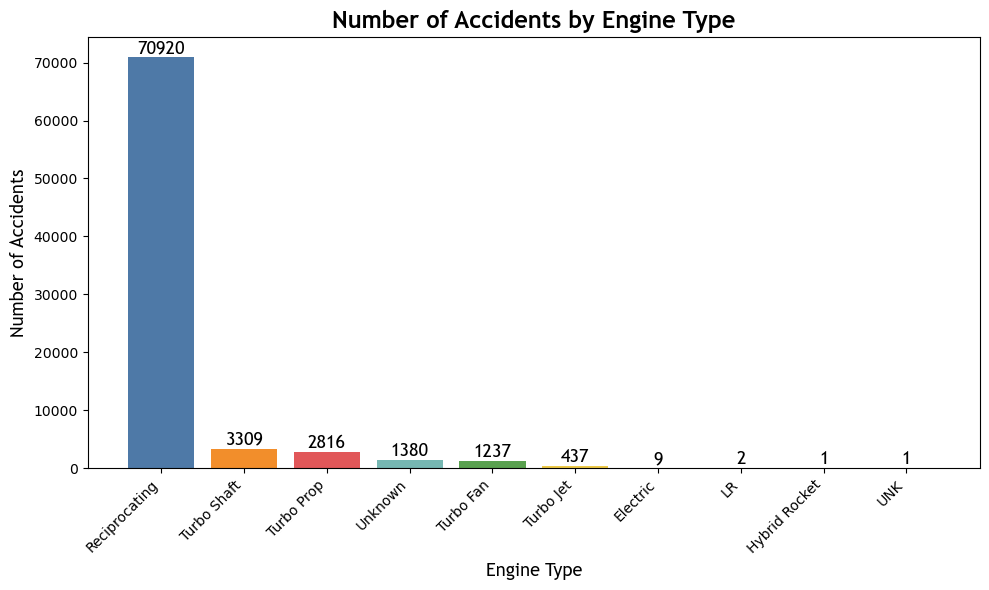

In [62]:
# Plotting the data
fig, ax = plt.subplots(figsize=(10, 6))  # Set the figure size
x=accidents_by_engine_type.index
heights=accidents_by_engine_type.values
bars = ax.bar(x,heights,color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948'])

# Rotating x-axis labels for better readability
ax.set_xticks(x)  # Set x-ticks to match the x values
ax.set_xticklabels(x, rotation=45, ha='right')

# Adding value labels on the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'{int(height)}', ha='center', va='bottom', fontsize=13, fontname='Trebuchet Ms',color='black')

# Adding title and labels
ax.set_title('Number of Accidents by Engine Type', fontname='Trebuchet Ms',fontsize=17, fontweight='bold')
ax.set_xlabel('Engine Type', fontsize=13,fontname='Trebuchet Ms')
ax.set_ylabel('Number of Accidents', fontsize=13,fontname='Trebuchet Ms')
# Show the plot
plt.tight_layout()
plt.show()

In [63]:
#count of accident over the years
# Filter the data for accidents only
accidents_only = Clean_aviation_data_merged[Clean_aviation_data_merged['Investigation.Type'] == 'Accident']


# Create the pivot table to count accidents per year
Accidents_trend = pd.pivot_table(
    accidents_only,
    index='Year',
    values='Investigation.Type',  # Counts the number of rows, which corresponds to accidents
    aggfunc=np.size
).reset_index()
print(Accidents_trend)
'''
Year 1982 experinced the highest number of accidents
The number of accidents post year 1983 is on a downward trend
Recent 10 years have experineced generally less number of accidents compared to previous periods
'''

    Year  Investigation.Type
0   1948                   1
1   1962                   1
2   1974                   1
3   1977                   1
4   1979                   2
5   1981                   1
6   1982                3455
7   1983                3409
8   1984                3306
9   1985                2983
10  1986                2769
11  1987                2680
12  1988                2547
13  1989                2421
14  1990                2416
15  1991                2361
16  1992                2243
17  1993                2180
18  1994                2144
19  1995                2163
20  1996                2055
21  1997                1977
22  1998                2038
23  1999                2040
24  2000                1990
25  2001                1860
26  2002                1834
27  2003                1892
28  2004                1738
29  2005                1804
30  2006                1613
31  2007                1763
32  2008                1642
33  2009      

'\nYear 1982 experinced the highest number of accidents\nThe number of accidents post year 1983 is on a downward trend\nRecent 10 years have experineced generally less number of accidents compared to previous periods\n'

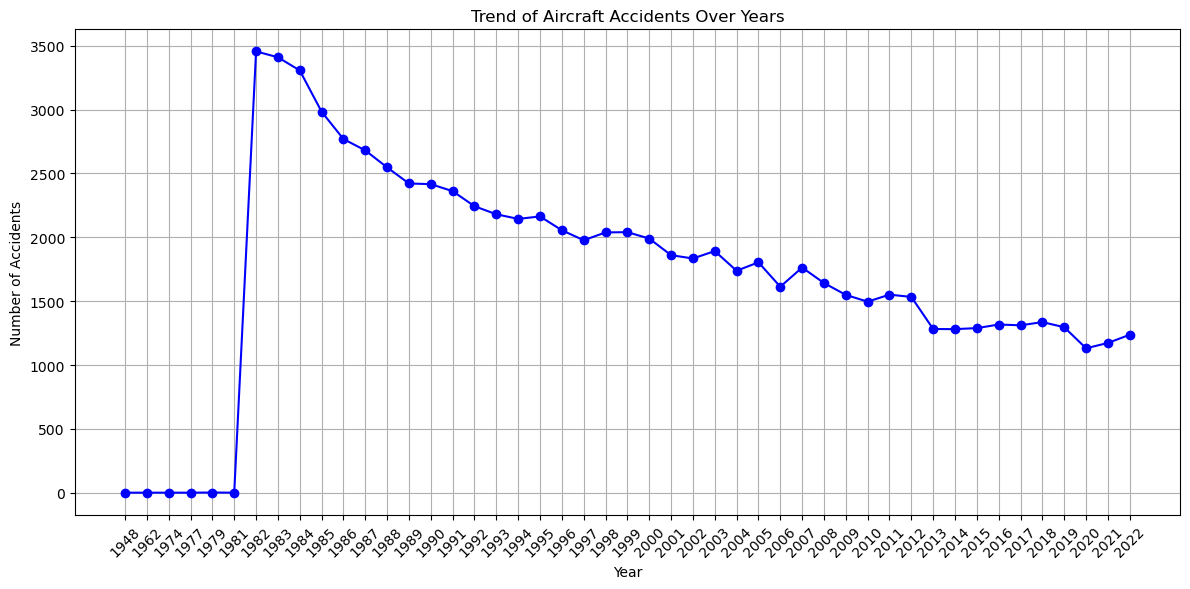

In [64]:
#representation of the above in a trend line graph
# Plotting the trend line graph
plt.figure(figsize=(12, 6))
plt.plot(Accidents_trend['Year'], Accidents_trend['Investigation.Type'], marker='o', linestyle='-', color='b')
plt.title('Trend of Aircraft Accidents Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better readability
plt.tight_layout()
plt.show()

In [65]:
#count of injuries over the years
count_of_injuries=pd.pivot_table(Clean_aviation_data_merged,index='Year',values=['Total.Fatal.Injuries','Total.Serious.Injuries','Total.Minor.Injuries',
                                                                                 'Total.Uninjured'],aggfunc=np.sum)
count_of_injuries


,Total.Fatal.Injuries,Total.Minor.Injuries,Total.Serious.Injuries,Total.Uninjured
Year,,,,
1948,2.0,0.0,0.0,0.0
1962,4.0,0.0,0.0,0.0
1974,3.0,0.0,0.0,5.0
1977,2.0,0.0,0.0,0.0
1979,2.0,1.0,2.0,44.0
1981,4.0,0.0,0.0,0.0
1982,1586.0,994.0,723.0,8227.0
1983,1274.0,1029.0,672.0,14665.0
1984,1237.0,1029.0,689.0,10935.0


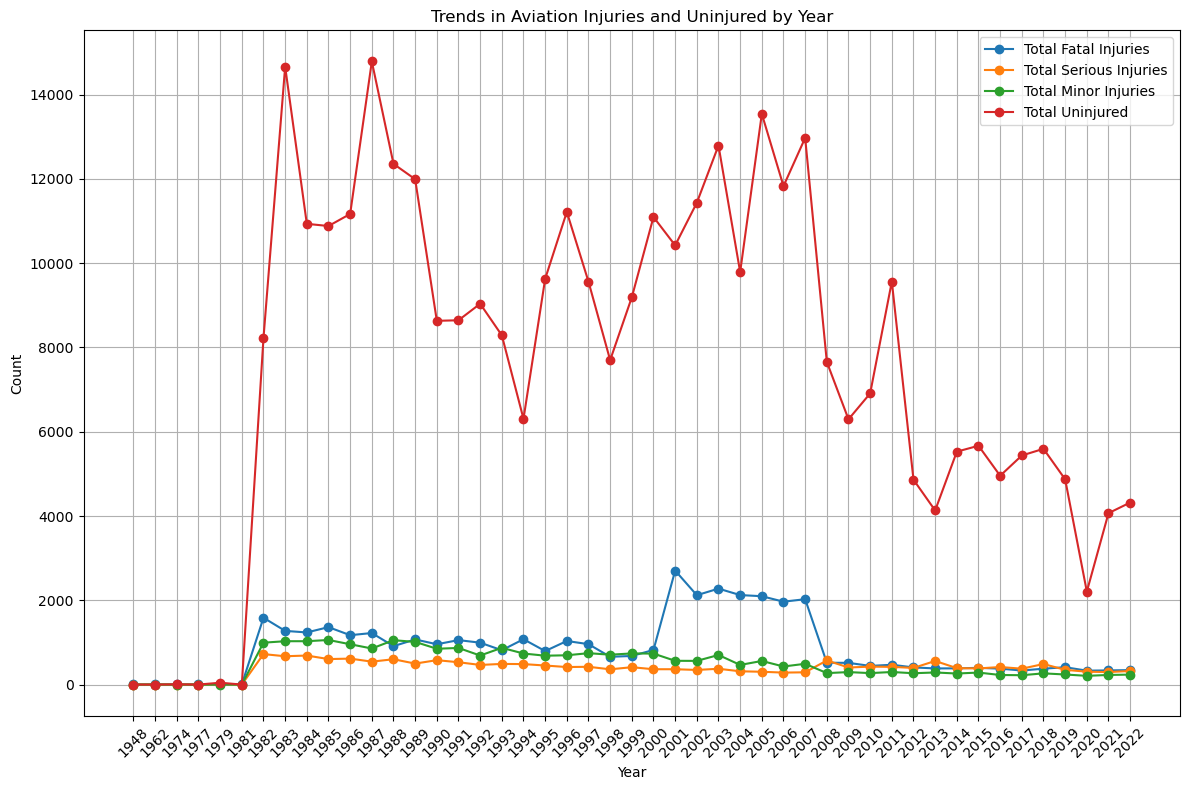

"'\nThe number of Total uninjured has significantly fallen over the years and is on a donward trend over the last 10 years\nThe number of Total fatal injuries has significantly fallen over the years and is on a donwatd trend over the last 10 years\nThe number of Total minor injuries has significantly fallen over the years and is on a donwatd trend over the last 10 years\n The number of Total serious injuries has significantly fallen over the years and is on a donwatd trend over the last 10 years\n"

In [66]:
# Plotting
plt.figure(figsize=(12, 8))

# Plot for Total Fatal Injuries
plt.plot(count_of_injuries.index, count_of_injuries['Total.Fatal.Injuries'], label='Total Fatal Injuries', marker='o')

# Plot for Total Serious Injuries
plt.plot(count_of_injuries.index, count_of_injuries['Total.Serious.Injuries'], label='Total Serious Injuries', marker='o')

# Plot for Total Minor Injuries
plt.plot(count_of_injuries.index, count_of_injuries['Total.Minor.Injuries'], label='Total Minor Injuries', marker='o')

# Plot for Total Uninjured
plt.plot(count_of_injuries.index, count_of_injuries['Total.Uninjured'], label='Total Uninjured', marker='o')

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Trends in Aviation Injuries and Uninjured by Year')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Rotate year labels for better readability

# Show the plot
plt.tight_layout()
plt.show()
''''
The number of Total uninjured has significantly fallen over the years and is on a donward trend over the last 10 years
The number of Total fatal injuries has significantly fallen over the years and is on a donwatd trend over the last 10 years
The number of Total minor injuries has significantly fallen over the years and is on a donwatd trend over the last 10 years
 The number of Total serious injuries has significantly fallen over the years and is on a donwatd trend over the last 10 years
'''

In [67]:
# Convert the 'Year' column to integers
Clean_aviation_data_merged['Year'] = pd.to_numeric(Clean_aviation_data_merged['Year'], errors='coerce')

# Find the most recent year in the dataset
latest_year = Clean_aviation_data_merged['Year'].max()

# Calculate the start year for the last 10 years
start_year = int(latest_year) - 10

# Filter data for the last 10 years
filtered_data = Clean_aviation_data_merged[Clean_aviation_data_merged['Year'] >= start_year]

# Create the pivot table for the filtered data
count_of_injuries_last_10_yrs= pd.pivot_table(filtered_data,
                                   index='Year',
                                   values=['Total.Fatal.Injuries', 'Total.Serious.Injuries',
                                           'Total.Minor.Injuries', 'Total.Uninjured'],
                                   aggfunc=np.sum)


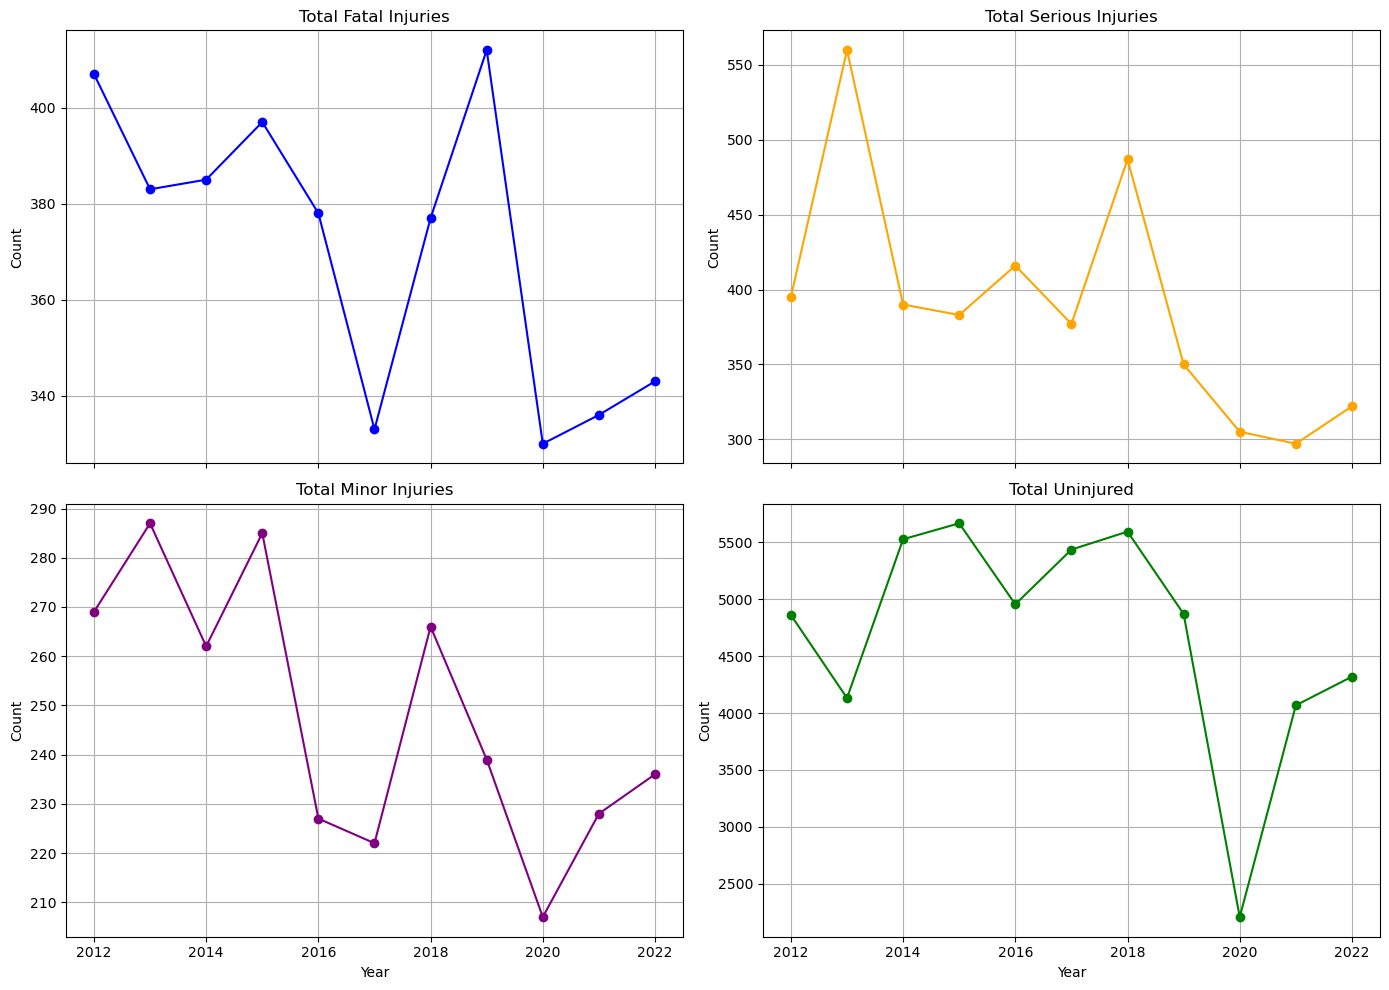

In [68]:
# Recent Trend analysis of Type of injuries over the last 10 years
# Set up the figure and axes for a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Plot for Total Fatal Injuries for the last 10 years
axes[0, 0].plot(count_of_injuries_last_10_yrs.index, count_of_injuries_last_10_yrs['Total.Fatal.Injuries'], color='blue', marker='o')
axes[0, 0].set_title('Total Fatal Injuries')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True)

# Plot for Total Serious Injuries
axes[0, 1].plot(count_of_injuries_last_10_yrs.index, count_of_injuries_last_10_yrs['Total.Serious.Injuries'], color='orange', marker='o')
axes[0, 1].set_title('Total Serious Injuries')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True)

# Plot for Total Minor Injuries
axes[1, 0].plot(count_of_injuries_last_10_yrs.index, count_of_injuries_last_10_yrs['Total.Minor.Injuries'], color='purple', marker='o')
axes[1, 0].set_title('Total Minor Injuries')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Year')
axes[1, 0].grid(True)

# Plot for Total Uninjured
axes[1, 1].plot(count_of_injuries_last_10_yrs.index, count_of_injuries_last_10_yrs['Total.Uninjured'], color='green', marker='o')
axes[1, 1].set_title('Total Uninjured')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('Year')
axes[1, 1].grid(True)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [69]:
# Analysis of number of accidents by number of engines Number.of.Engines,  Engine.Type
Accidents_by_engines=pd.pivot_table(Clean_aviation_data_merged,index='Number.of.Engines',values=['Investigation.Type'],aggfunc=np.size).reset_index()
Accidents_by_engines
'''
Aircrafts with 1 engine experinced huge number of accidents i.e., 70,425 as compared with those with 2 engine i.e., 10,158 accidents.
'''

'\nAircrafts with 1 engine experinced huge number of accidents i.e., 70,425 as compared with those with 2 engine i.e., 10,158 accidents.\n'

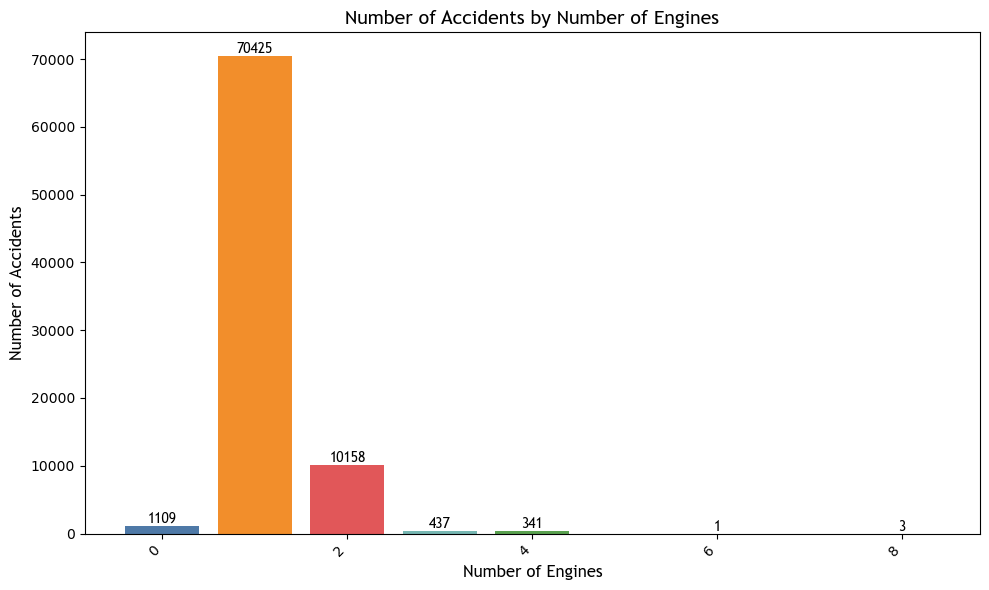

In [70]:
# Define the data for plotting
x = Accidents_by_engines['Number.of.Engines']
heights = Accidents_by_engines['Investigation.Type']

# Create the figure and axis for the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create the bar chart
bars = ax.bar(x, heights, color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', 
          '#9b8d82', '#b07d72', '#a2c2e0', '#7f8c8d'])

# Add labels to the bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate: center of the bar
        height,  # Y-coordinate: top of the bar
        f'{height}',  # Text: height of the bar
        ha='center',  # Horizontal alignment: center
        va='bottom',  # Vertical alignment: just above the bar
        fontname='Trebuchet MS'
    )

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Set the title and labels
bar_chart_title = 'Number of Accidents by Number of Engines'
bar_chart_count_label = 'Number of Accidents'
bar_chart_series_label = 'Number of Engines'

ax.set_title(bar_chart_title, fontname='Trebuchet MS', fontsize=14)
ax.set_xlabel(bar_chart_series_label, fontname='Trebuchet MS', fontsize=12)
ax.set_ylabel(bar_chart_count_label, fontname='Trebuchet MS', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()

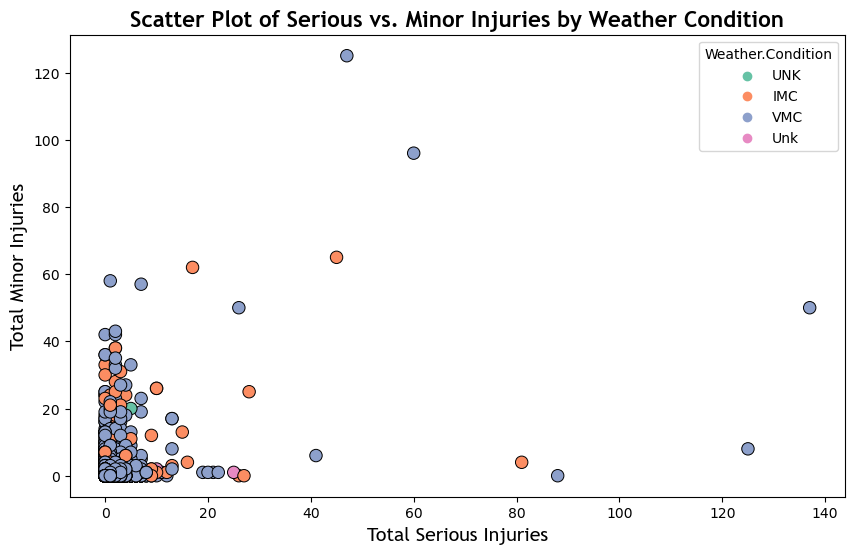

'\nMost accidents seem to result in fewer than 20 serious injuries and fewer than 40 minor injuries. \nThe data is highly concentrated in this lower range, indicating that many accidents involve a relatively small number of injuries.\n\nAccidents under VMC (green) and IMC (orange) are scattered throughout, but both types of weather conditions have a wide \nrange of outcomes. However, VMC accidents appear more frequently, which may imply more accidents happen under clear weather (or visually navigable conditions).\n\nA few outliers can be observed where accidents involve more than 40 serious or minor injuries. These could represent catastrophic accidents with higher injury counts.\n'

In [71]:
#Scatter Plot of Serious vs. Minor Injuries by Weather Condition'
plt.figure(figsize=(10, 6))  # Adjust the figure size for better visualization
sns.scatterplot(x=Clean_aviation_data_merged['Total.Serious.Injuries'], 
                y=Clean_aviation_data_merged['Total.Minor.Injuries'], 
                hue=Clean_aviation_data_merged['Weather.Condition'], 
                palette='Set2',  # A softer color palette for better distinction
                s=80,  # Increase marker size
                edgecolor='black')  # Add edge color for better marker visibility

# Adding labels and title
plt.title('Scatter Plot of Serious vs. Minor Injuries by Weather Condition', fontsize=16, fontweight='bold',fontname='Trebuchet Ms')
plt.xlabel('Total Serious Injuries', fontsize=14, fontname='Trebuchet Ms')
plt.ylabel('Total Minor Injuries', fontsize=14,fontname='Trebuchet Ms')

# Show plot
plt.show()

'''
Most accidents seem to result in fewer than 20 serious injuries and fewer than 40 minor injuries. 
The data is highly concentrated in this lower range, indicating that many accidents involve a relatively small number of injuries.

Accidents under VMC (green) and IMC (orange) are scattered throughout, but both types of weather conditions have a wide 
range of outcomes. However, VMC accidents appear more frequently, which may imply more accidents happen under clear weather (or visually navigable conditions).

A few outliers can be observed where accidents involve more than 40 serious or minor injuries. These could represent catastrophic accidents with higher injury counts.
'''

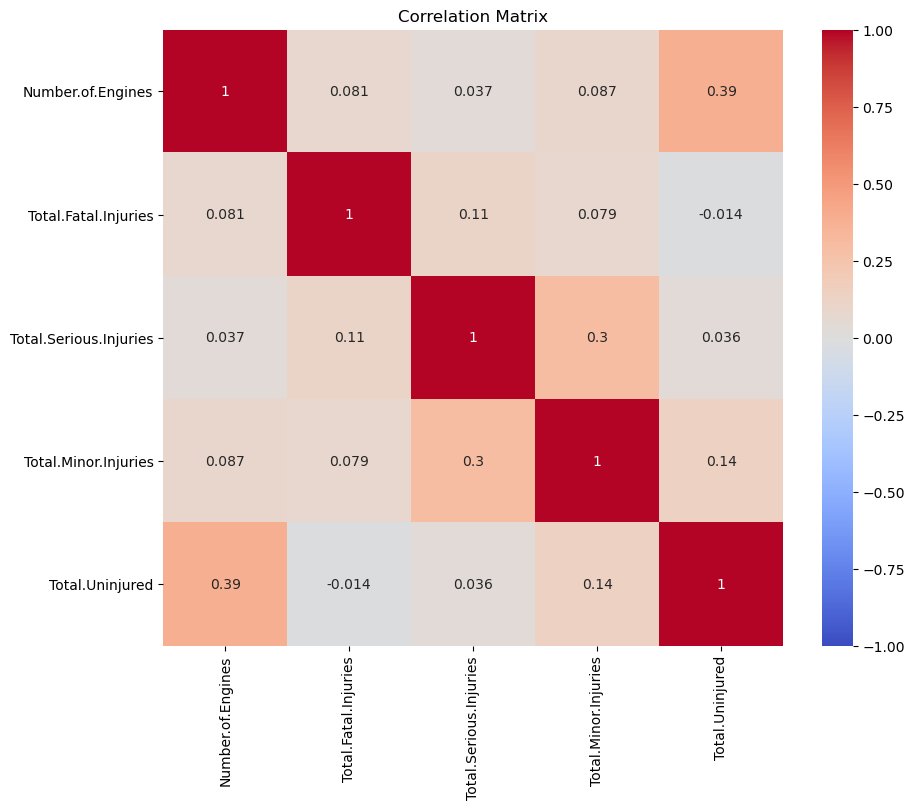

'\nPositive Correlations:\nNumber of Engines and Total Uninjured (0.39): Indicates that as the number of engines increases, there is a moderate \npositive correlation with the number of uninjured individuals. Aircraft with more engines may provide better safety in accidents, leading to more survivors.\nTotal Serious Injuries and Total Minor Injuries (0.30): This shows a moderate correlation, meaning that accidents with a higher number of serious injuries tend to also involve more minor injuries.\nWeak Correlations:\nMost other variables, such as Total Fatal Injuries with other injury categories, have weak positive correlations (close to 0). This suggests that while there is some relationship, it’s very weak or no relationship.\n'

In [72]:
#Correlation matrix for numerical values
numerical_data = Clean_aviation_data_merged.select_dtypes(include='number').drop(columns='Year')
# Generate the correlation matrix
correlation_matrix = numerical_data.corr()
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

'''
Positive Correlations:
Number of Engines and Total Uninjured (0.39): Indicates that as the number of engines increases, there is a moderate 
positive correlation with the number of uninjured individuals. Aircraft with more engines may provide better safety in accidents, leading to more survivors.
Total Serious Injuries and Total Minor Injuries (0.30): This shows a moderate correlation, meaning that accidents with a higher number of serious injuries tend to also involve more minor injuries.
Weak Correlations:
Most other variables, such as Total Fatal Injuries with other injury categories, have weak positive correlations (close to 0). This suggests that while there is some relationship, it’s very weak or no relationship.
'''

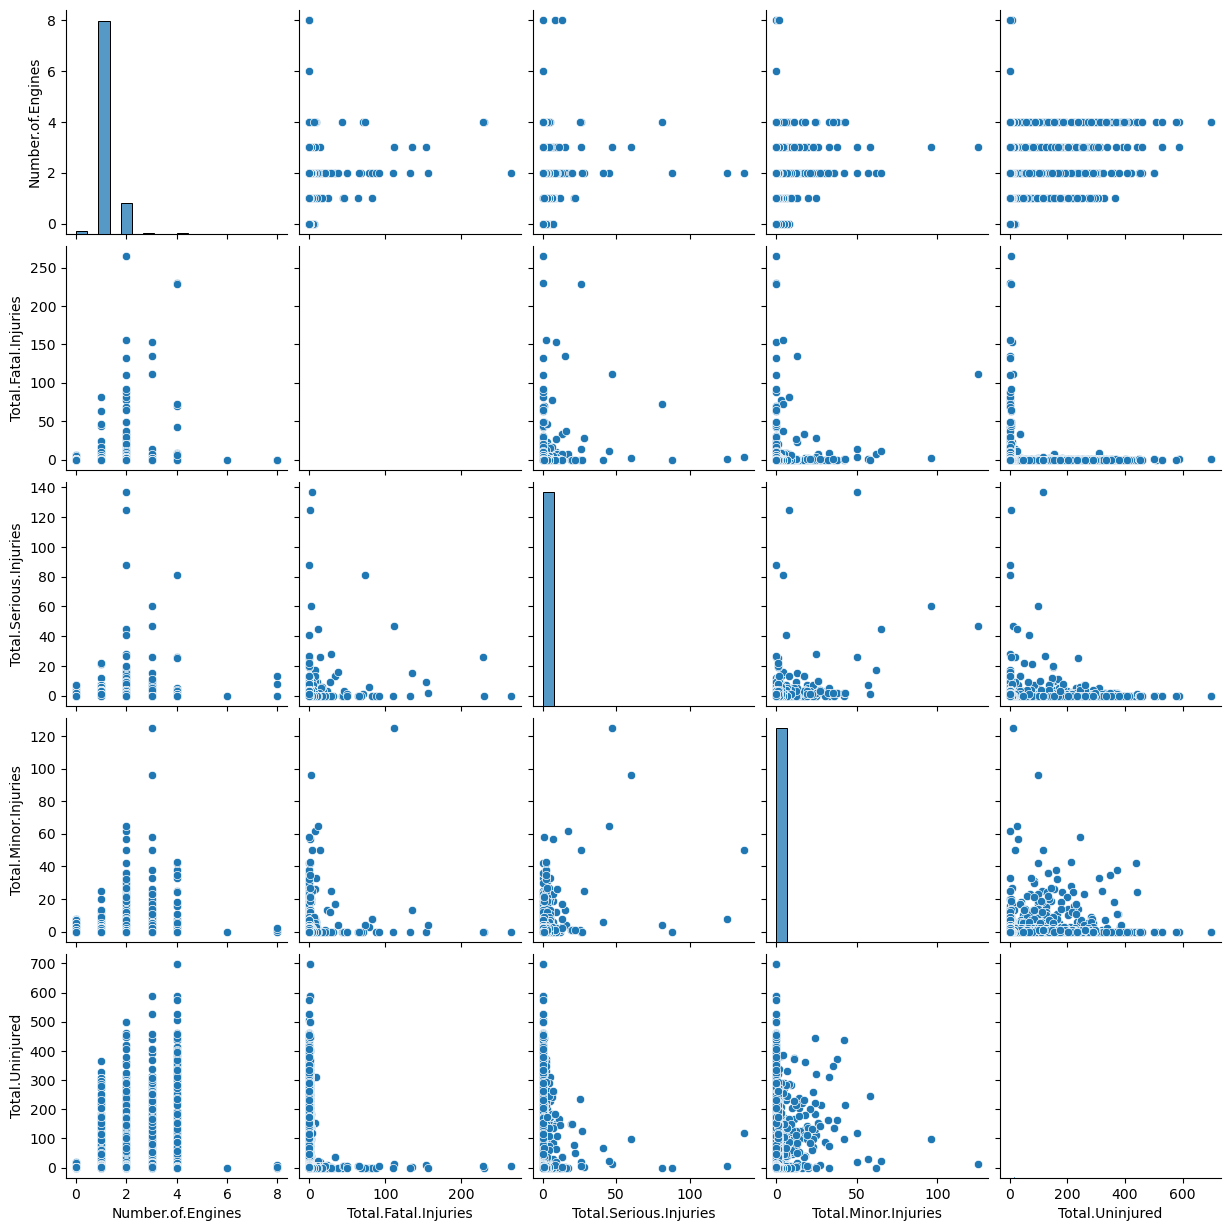

In [73]:
# Represnettaion of the above findings in a graph
# scatter plots to show the relationships
numerical_data = Clean_aviation_data_merged.select_dtypes(include='number').drop(columns='Year')

# Create scatter plots for each pair of numerical variables
sns.pairplot(numerical_data)

# Display the plot
plt.show()

# 4.0 CONCLUSION
Based on our analysis, we conclude as follows:
- **Number of engines:**
Aircrafts with 1 engine are involved in the vast majority of accidents. Aircraft with 2 engines show a significantly lower number of accident investigations compared to single-engine aircraft, likely because dual-engine setups provide redundancy in case of engine failure, lowering the risk. 
- **Weather conditions:**
The vast majority of accidents occur under VMC, likely because these conditions are far more common than IMC (Instrument Meteorological Conditions).
- **Location:**
Anchorage, Alaska, has the highest number of recorded aircraft accidents. Other locations such as Albuquerque,Houston,Miami experinec relatively low number of accidents as compared to Ancholarge AK.
- **Flight purpose:**
The overwhelming majority of accidents are associated with personal flights. This may be due to the higher volume of personal flights compared to other categories.Business flights, which are typically more organized and may involve more professional pilots, have fewer accidents compared to personal flights. This suggests that these flights are generally safer due to more stringent operational and maintenance practices.
- **Trend aalysis for number of accidents across the years:**
Year 1982 recorded the highest number of accidents.
After the initial spike, the number of accidents seems to generally decrease over time. This could indicate improvements in safety or changes in reporting standards.
Recent Years( i.e. past 10 years): The number of accidents in recent years (2012-2022) appears to be lower compared to earlier years, suggesting a positive trend in reducing accidents.
- **Aircraft Makes and Models:**
CESSNA and PIPER are the most frequently involved in accidents, which could be due to their high number of flights or other factors.
BOEING and BELL, while having fewer accidents compared to CESSNA and PIPER, still have significant numbers, likely due to their widespread use in commercial aviation.

152 and 172 are the most frequently involved models in accidents, reflecting their high usage and possibly their operational profiles.
PA-28-140 and 150 also show notable accident rates, which could be linked to their operational contexts or frequency of use.
- **Injury types:**
Fatal injuries have generally decreased, while the number of minor and serious injuries shows varying patterns. 
The number of uninjured individuals also fluctuates, which may reflect changes in the number of accidents or improvements in safety measures. Notably, the total number of injuries and uninjured individuals has shown a decreasing trend in recent years, suggesting overall improvements in aviation safety.
- **correlation analysis:**
Number of Engines shows a moderate positive correlation with the number of uninjured individuals, suggesting that aircraft with more engines tend to have a higher number of uninjured passengers. Other correlations involving the number of engines are weak.
Total Fatal Injuries has weak positive correlations with serious and minor injuries, indicating some association but not a strong one.
Total Serious Injuries has a moderate positive correlation with minor injuries, suggesting that more serious injuries are somewhat associated with more minor injuries.
Overall, the relationships among these variables are generally weak, with a notable moderate correlation between serious and minor injuries.





# 5.0 Rcommendations
1. **Number of Engines:** Opt for aircraft with at least 2 engines. Dual-engine aircraft generally have lower accident rates due to redundancy in case of engine failure.
2. **Weather Considerations:** While accidents are more frequent under VMC (Visual Meteorological Conditions), ensure the aircraft is equipped to handle a range of weather conditions, including IMC (Instrument Meteorological Conditions), for added safety.
3. **Location:** Consider operational history and risk factors of specific regions. Aircraft based in or frequently flying to high-accident locations like Anchorage, Alaska, may face higher risks. The business can consider other routes other thanAnchorage, Alaska.
4. **Flight Purpose:** Prioritize aircraft used primarily for business or professional purposes over those used for personal flights, as business flights typically have lower accident rates due to stricter operational standards.
5. **Avoid High-Accident Makes:** The top makes with the highest number of accidents are:
CESSNA: 27,212 accidents
PIPER: 14,870 accidents
BEECH: 5,372 accidents
If safety is a primary concern, you might consider aircraft from makes with fewer accidents.
Makes with fewer accidents such as MOONEY (1,334) or ROBINSON (1,230) might offer better safety profiles. 

Avoid High-Accident Models: The top models with the highest number of accidents are:
152: 2,459 accidents
172: 1,756 accidents
172N: 1,164 accidents
Models with fewer accidents such as 150M (585) might be better choices for enhanced safety.

6. **Trend Analysis:** Choose newer aircraft models or those with recent safety updates, as the trend indicates decreasing accident rates over time and improvements in aviation safety.


